# CSV Parsing Robustness Evaluation

**CIDR 2027 submission figures.** This notebook summarizes system-level parsing
quality and analyzes errors by pollution category. Figures use a shared,
publication-oriented visual style and are exported at print resolution.

In [1]:
# Core analysis and plotting dependencies
from pathlib import Path
import textwrap

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter

In [2]:
# Shared CIDR-style figure theme
CIDR_DOUBLE_COLUMN = 7.00697
CIDR_SINGLE_COLUMN = 3.3374

CIDR_COLORS = {
    "navy": "#2E4A62",
    "burgundy": "#9E3D49",
    "teal": "#4F7C78",
    "gold": "#B58B3A",
    "slate": "#66717E",
    "light": "#E8EBEE",
    "text": "#252A30",
}

mpl.rcParams.update(
    {
        "figure.figsize": (CIDR_DOUBLE_COLUMN, 3.4),
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.family": "serif",
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.titleweight": "semibold",
        "axes.labelsize": 9,
        "axes.edgecolor": "#A7ADB4",
        "axes.linewidth": 0.7,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "text.color": CIDR_COLORS["text"],
        "axes.labelcolor": CIDR_COLORS["text"],
        "xtick.color": CIDR_COLORS["text"],
        "ytick.color": CIDR_COLORS["text"],
    }
)

def find_repo_root() -> Path:
    """Locate the repository whether the notebook runs from root or its own folder."""
    start = Path.cwd().resolve()
    for candidate in (start, *start.parents):
        if (candidate / "eval" / "sut_error_summary.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate eval/sut_error_summary.csv")


REPO_ROOT = find_repo_root()
SUMMARY_PATH = REPO_ROOT / "eval" / "sut_error_summary.csv"

SUT_LABELS = {
    "clevercs": "CleverCSV",
    "csvcommons": "CSV Commons",
    "duckdbauto": "DuckDB Auto",
    "duckdbparse": "DuckDB Explicit",
    "mysql": "MySQL",
    "opencsv": "OpenCSV",
    "pandas": "Pandas",
    "postgres": "PostgreSQL",
    "pycsv": "Python csv",
    "rcsv": "R csv",
    "sqlite": "SQLite",
    "univocity": "UniVocity",
}


def display_sut_name(name: str) -> str:
    return SUT_LABELS.get(name, name.replace("_", " ").title())


def style_paper_axis(ax, *, grid_axis: str = "x") -> None:
    ax.grid(axis=grid_axis, color="#D8DCE0", linewidth=0.6, alpha=0.75)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)


def select_top_suts(summary_data: pd.DataFrame, n: int = 5) -> list[str]:
    overall = summary_data.loc[summary_data["pollution_group"].eq("ALL")]
    return overall.nsmallest(n, "error_rate")["sut"].tolist()

### CSV Storm evaluation summary

Load and display the aggregate CSV Storm evaluation results.

In [ ]:
CSV_STORM_SUMMARY_PATH = REPO_ROOT / "results" / "evaluation_summary_csv_storm.csv"
csv_storm_results = pd.read_csv(CSV_STORM_SUMMARY_PATH)

#TODO sort by accuracy 
csv_storm_results.sort_values(by="accuracy", ascending= False)

,sut,success,header_precision,header_recall,header_f1,record_precision,record_recall,record_f1,cell_precision,cell_recall,cell_f1,pollock_simple,correct,wrong,accuracy,weighted_accuracy,pollock_weighted,score
3,llm_hybrid_parser_gpt_5_6_clevercsv,1.000000,0.955882,0.955882,0.955882,0.995927,0.996574,0.996246,0.998426,0.999040,0.998728,9.852587,54,14,0.794118,0.794118,9.852587,54
9,llm_hybrid_parser_gpt_5_6,0.985294,0.941176,0.941176,0.941176,0.950746,0.951393,0.951065,0.954542,0.984218,0.955185,9.555973,50,18,0.735294,0.735294,9.555973,50
4,llm_hybrid_parser_gpt_5_4_mini_clevercsv,1.000000,0.955882,0.955882,0.955882,0.938521,0.938352,0.938433,0.979791,0.979553,0.979668,9.621964,43,25,0.632353,0.632353,9.621964,43
0,llm_hybrid_parser,0.867647,0.823529,0.823529,0.823529,0.844261,0.848255,0.845919,0.847593,0.866531,0.849590,8.440385,42,26,0.617647,0.617647,8.440385,42
1,llm_hybrid_parser_gpt_5_4_mini,0.867647,0.823529,0.823529,0.823529,0.806345,0.805999,0.806169,0.820535,0.849184,0.820667,8.247135,36,32,0.529412,0.529412,8.247135,36
7,duckdbparse,1.000000,0.955882,0.952206,0.953782,0.897236,0.894826,0.896016,0.954729,0.976199,0.960961,9.441836,29,39,0.426471,0.426471,9.441836,29
8,code_generation_llm_gpt_5_4_mini,1.000000,0.875817,0.847019,0.848132,0.866763,0.875451,0.870419,0.913090,0.920221,0.906425,8.923339,29,39,0.426471,0.426471,8.923339,29
2,full_llm_loader_naive_gpt_5_4_mini,0.544118,0.513072,0.514706,0.513841,0.529057,0.543597,0.529231,0.527136,0.543259,0.528301,5.286317,24,44,0.352941,0.352941,5.286317,24
10,llm_hybrid_parser_qwen3_5_0_8b,1.000000,0.717320,0.794118,0.742322,0.695074,0.705293,0.699593,0.726675,0.830262,0.738718,7.649376,21,47,0.308824,0.308824,7.649376,21
14,pandas,0.426471,0.323529,0.323529,0.323529,0.318214,0.334270,0.320867,0.329093,0.349909,0.333487,3.382897,12,56,0.176471,0.176471,3.382897,12


## 1. System-Level Performance

The following figures report aggregate parsing quality before breaking errors
down by pollution category.

### Overall parsing quality

Average cell F1 and file-level error rate are shown on a common percentage
scale. Systems are ordered by decreasing cell F1.

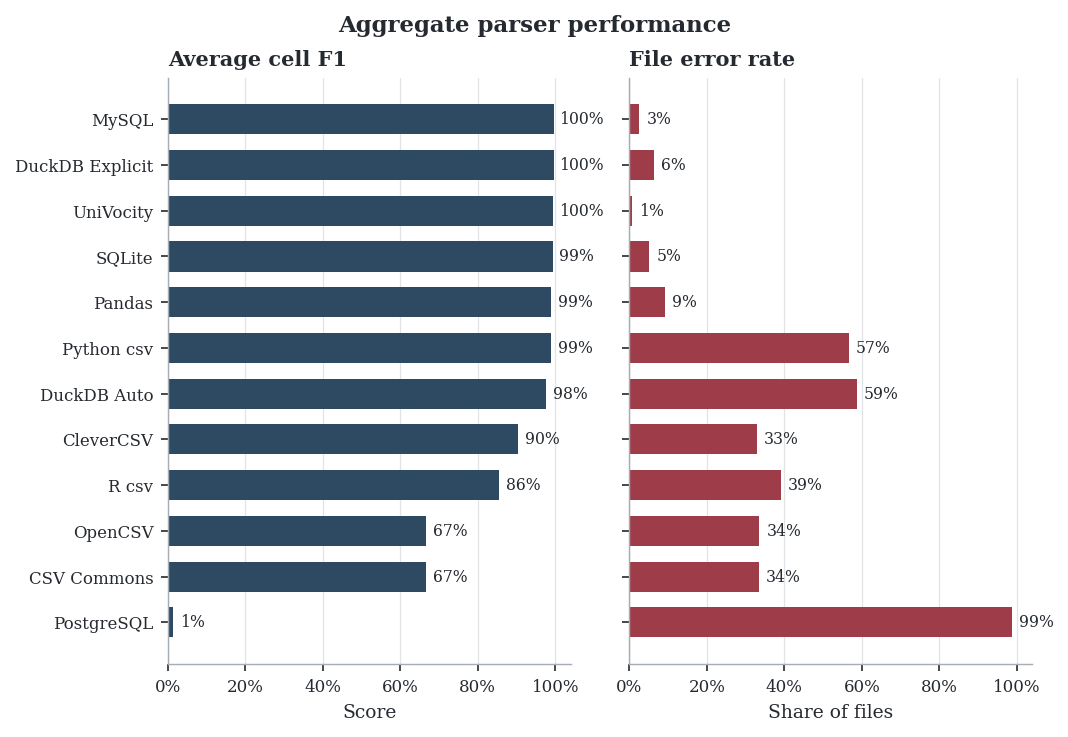

In [4]:
summary_data = pd.read_csv(SUMMARY_PATH)
overall = (
    summary_data.loc[summary_data["pollution_group"].eq("ALL")]
    .sort_values("avg_cell_f1")
    .copy()
)
overall["label"] = overall["sut"].map(display_sut_name)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(CIDR_DOUBLE_COLUMN, 4.8),
    sharey=True,
    constrained_layout=True,
)

panels = [
    ("avg_cell_f1", "Average cell F1", CIDR_COLORS["navy"]),
    ("error_rate", "File error rate", CIDR_COLORS["burgundy"]),
]
for ax, (column, title, color) in zip(axes, panels):
    bars = ax.barh(overall["label"], overall[column], color=color, height=0.66)
    ax.set_title(title, loc="left")
    ax.set_xlim(0, 1.04)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("Score")
    style_paper_axis(ax)
    for bar, value in zip(bars, overall[column]):
        ax.text(
            min(value + 0.018, 1.01),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.0%}",
            va="center",
            fontsize=7.5,
        )

axes[1].set_xlabel("Share of files")
fig.suptitle("Aggregate parser performance", fontsize=11, fontweight="semibold")
plt.show()

### Accuracy and Pollock Simple score for selected systems

The two metrics use separate panels to avoid a misleading dual-axis
comparison while retaining the original selected-system view.

In [5]:
def plot_sut_comparison(data: pd.DataFrame):
    """Plot accuracy and Pollock Simple score in a compact two-panel layout."""
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(CIDR_DOUBLE_COLUMN, 2.8),
        constrained_layout=True,
    )

    specifications = [
        ("accuracy_pct", "Accuracy", CIDR_COLORS["navy"], (0, 100), "{:.1f}%"),
        ("pollock_simple", "Pollock Simple score", CIDR_COLORS["teal"], (9.5, 10.02), "{:.3f}"),
    ]
    x = np.arange(len(data))

    for ax, (column, title, color, limits, value_format) in zip(axes, specifications):
        bars = ax.bar(x, data[column], width=0.62, color=color)
        ax.set_title(title, loc="left")
        ax.set_xticks(x, data["SuT"])
        ax.set_ylim(*limits)
        style_paper_axis(ax, grid_axis="y")
        for bar, value in zip(bars, data[column]):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + (limits[1] - limits[0]) * 0.025,
                value_format.format(value),
                ha="center",
                va="bottom",
                fontsize=7.5,
            )

    axes[0].set_ylabel("Share of correctly parsed files")
    axes[0].yaxis.set_major_formatter(PercentFormatter(100))
    axes[1].set_ylabel("Score")
    return fig, axes

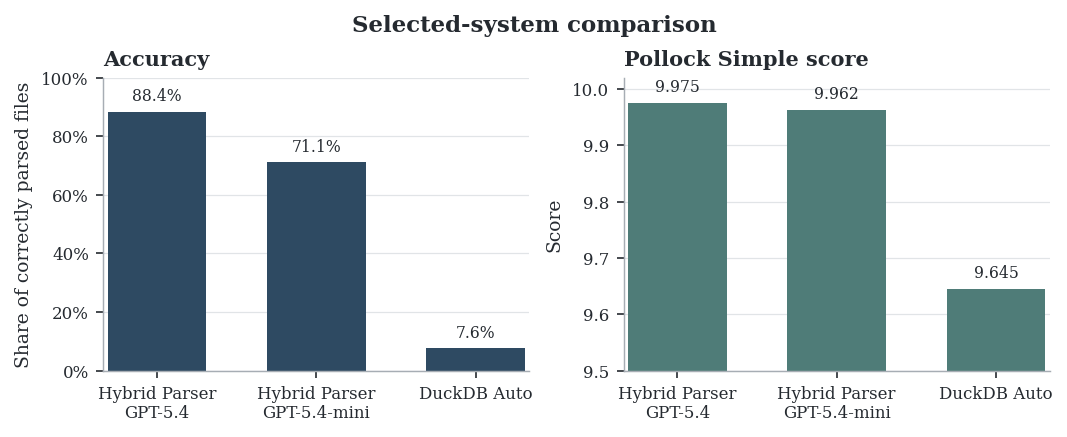

In [6]:
selected_systems = pd.DataFrame(
    {
        "SuT": [
            "Hybrid Parser\nGPT-5.4",
            "Hybrid Parser\nGPT-5.4-mini",
            "DuckDB Auto",
        ],
        "accuracy_pct": [88.3893, 71.0607, 7.6386],
        "pollock_simple": [9.975212, 9.962150, 9.645],
    }
)

fig, axes = plot_sut_comparison(selected_systems)
fig.suptitle("Selected-system comparison", fontsize=11, fontweight="semibold")
plt.show()

### Error rates for the five strongest systems

For readability, the comparison focuses on the ten pollution groups with the
highest mean error rate among the five best aggregate performers.

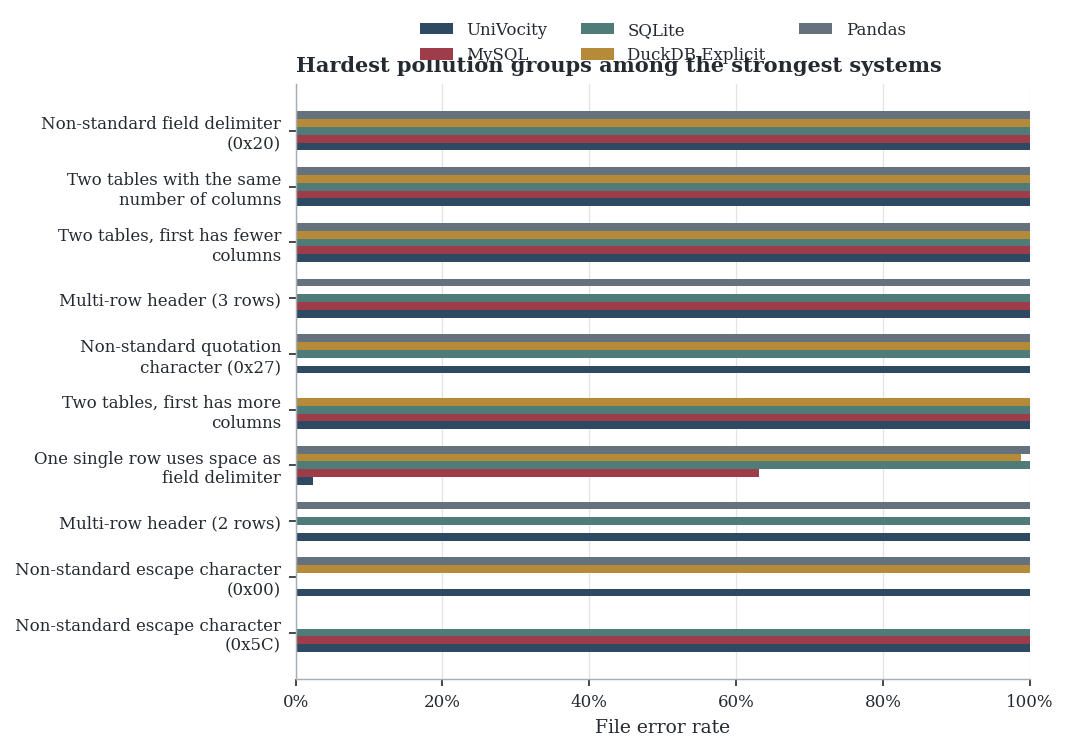

In [7]:
top_suts = select_top_suts(summary_data)
by_pollution = summary_data.loc[
    summary_data["pollution_group"].ne("ALL")
    & summary_data["sut"].isin(top_suts)
].copy()

hardest_groups = (
    by_pollution.groupby("pollution_group")["error_rate"]
    .mean()
    .nlargest(10)
    .index
)
error_matrix = (
    by_pollution.loc[by_pollution["pollution_group"].isin(hardest_groups)]
    .pivot_table(index="pollution_group", columns="sut", values="error_rate")
    .reindex(hardest_groups[::-1])
)

fig, ax = plt.subplots(figsize=(CIDR_DOUBLE_COLUMN, 4.9), constrained_layout=True)
y = np.arange(len(error_matrix))
bar_height = 0.14
palette = [
    CIDR_COLORS["navy"],
    CIDR_COLORS["burgundy"],
    CIDR_COLORS["teal"],
    CIDR_COLORS["gold"],
    CIDR_COLORS["slate"],
]

for offset, (sut, color) in enumerate(zip(top_suts, palette)):
    ax.barh(
        y + (offset - 2) * bar_height,
        error_matrix[sut],
        height=bar_height,
        label=display_sut_name(sut),
        color=color,
    )

ax.set_yticks(
    y,
    [textwrap.fill(label.replace("_", " "), 29) for label in error_matrix.index],
)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_xlabel("File error rate")
ax.set_title("Hardest pollution groups among the strongest systems", loc="left")
ax.legend(ncol=3, loc="lower center", bbox_to_anchor=(0.5, 1.01))
style_paper_axis(ax)
plt.show()

### Error concentration by system

Small multiples expose each leading system's most difficult pollution groups
without producing a sequence of oversized figures.

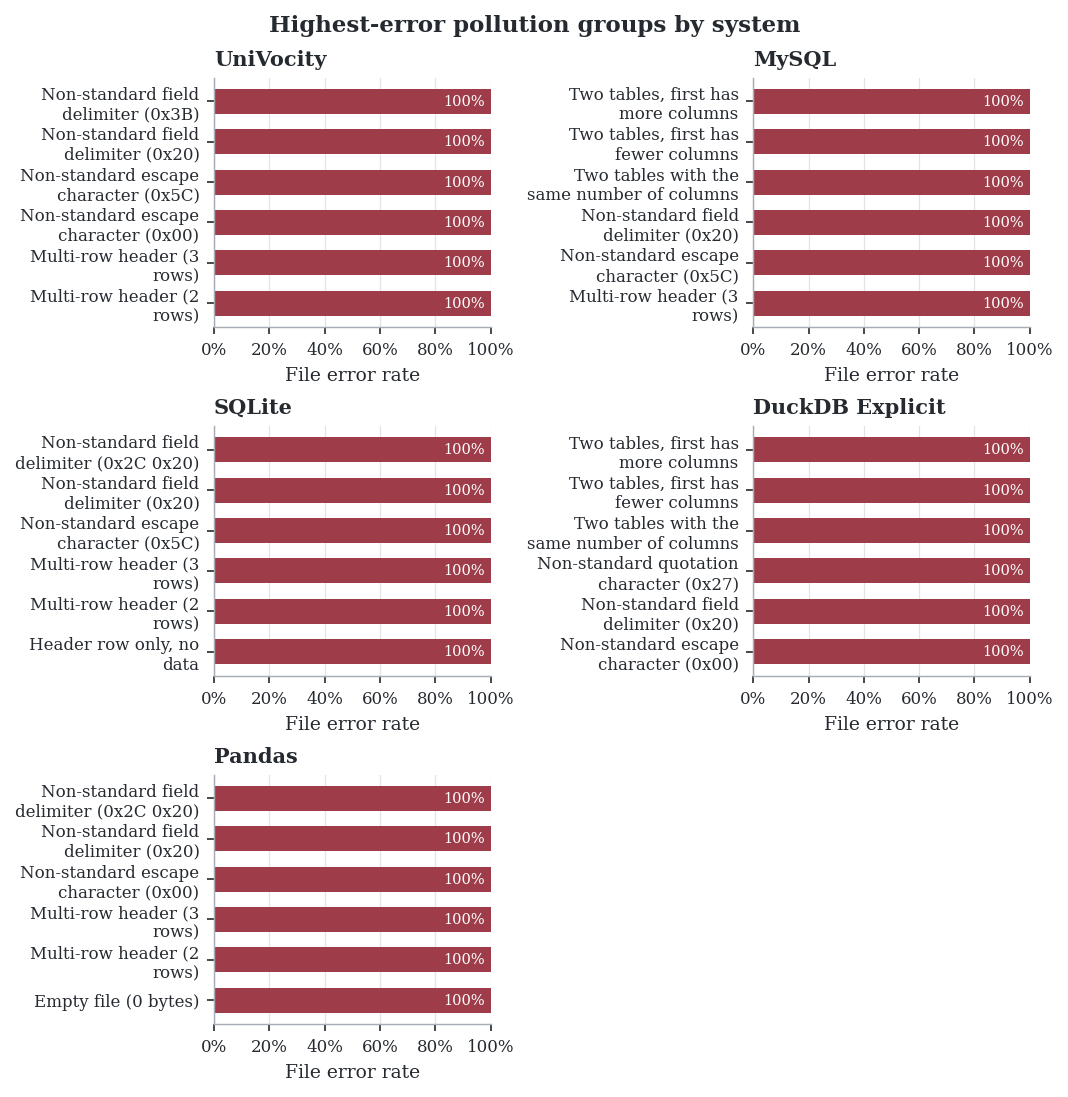

In [8]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(CIDR_DOUBLE_COLUMN, 7.2),
    constrained_layout=True,
)
flat_axes = axes.ravel()

for ax, sut in zip(flat_axes, top_suts):
    system_data = (
        by_pollution.loc[by_pollution["sut"].eq(sut)]
        .nlargest(6, "error_rate")
        .sort_values("error_rate")
    )
    labels = [
        textwrap.fill(label.replace("_", " "), 22)
        for label in system_data["pollution_group"]
    ]
    bars = ax.barh(
        labels,
        system_data["error_rate"],
        color=CIDR_COLORS["burgundy"],
        height=0.62,
    )
    ax.set_title(display_sut_name(sut), loc="left")
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.set_xlabel("File error rate")
    style_paper_axis(ax)
    for bar, value in zip(bars, system_data["error_rate"]):
        if value >= 0.12:
            ax.text(
                value - 0.02,
                bar.get_y() + bar.get_height() / 2,
                f"{value:.0%}",
                ha="right",
                va="center",
                color="white",
                fontsize=7,
            )

flat_axes[-1].axis("off")
fig.suptitle(
    "Highest-error pollution groups by system",
    fontsize=11,
    fontweight="semibold",
)
plt.show()

## Evaluation 2 - Statistics per Pollution Category

In [9]:
# Derive CSV Storm pollution categories from the @pollution metadata.
from pathlib import Path
import json
import re
import sys


def find_repo_root(start: Path) -> Path:
    """Find the repository root whether the notebook runs from root or its folder."""
    for candidate in (start, *start.parents):
        if (candidate / "pollock").is_dir() and (candidate / "results").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the Pollock repository root")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from pollution import polluters_stdlib_v1 as polluters_v1
from pollution import polluters_stdlib_v2 as polluters_v2


def recorded_csv_storm_model(sut_id: str) -> str:
    """Read the model identifier recorded by one CSV Storm LLM run."""
    run_dir = REPO_ROOT / "results" / sut_id / "csv_storm"
    time_path = run_dir / f"{sut_id}_time.csv"
    if time_path.exists():
        time_df = pd.read_csv(time_path)
        if "model" in time_df.columns:
            models = time_df["model"].dropna().astype(str).unique().tolist()
            if len(models) == 1:
                return models[0]
            if len(models) > 1:
                raise ValueError(f"Multiple models recorded in {time_path}: {models}")

    # The hybrid parser records its model in per-file LLM trace events.
    for trace_path in sorted((run_dir / "loading").glob("*.llm.jsonl")):
        with trace_path.open(encoding="utf-8") as trace_file:
            for line in trace_file:
                event = json.loads(line)
                if event.get("model"):
                    return str(event["model"])

    raise ValueError(f"No model metadata found for CSV Storm run: {sut_id}")


def display_model_name(model: str) -> str:
    """Format OpenAI model identifiers for publication labels."""
    return f"GPT-{model[4:]}" if model.lower().startswith("gpt-") else model

# Connect generated filenames to their polluter functions. The category and alias
# are then read from each function's decorator instead of duplicated here.
FILENAME_POLLUTER_ROUTES = (
    (r"^file_no_payload", polluters_v1.changeDimension),
    (r"^file_(no|double)_trailing_newline", polluters_v1.changeRowRecordDelimiter),
    (r"^file_(no_header|header_only|one_data_row)", polluters_v1.changeNumberRows),
    (r"^file_num_rows", polluters_v1.changeNumberRows),
    (r"^file_num_columns", polluters_v1.changeNumberColumns),
    (r"^file_header_multirow", polluters_v1.expandColumnHeader),
    (r"^file_preamble", polluters_v1.addPreamble),
    (r"^file_field_delimiter", polluters_v1.changeFieldDelimiter),
    (r"^file_quotation_char", polluters_v1.changeQuotationChar),
    (r"^file_escape_char", polluters_v1.changeEscapeCharacter),
    (r"^file_record_delimiter", polluters_v1.changeRecordDelimiter),
    (r"^row_quotation_mark", polluters_v1.changeRowQuotationMark),
    (r"^file_duplicate_header_as_data", polluters_v2.duplicateHeaderIntoRows),
    (r"^file_commented_row", polluters_v2.commentRow),
    (r"^file_more_columns", polluters_v2.moreColumns),
    (r"^file_less_columns_deleted_value", polluters_v2.lessColumnsDeletedValues),
    (r"^file_mixed_delimiters", polluters_v2.mixedDelimiters),
    (r"^file_multiline_header", polluters_v2.multilineHeader),
    (r"^file_superheader", polluters_v2.superheader),
    (r"^file_move_header", polluters_v2.moveHeaderRow),
    (r"^file_footnote", polluters_v2.addFootnote),
    (r"^file_extremely_long_field", polluters_v2.extremelyLongFields),
    (r"^file_unescaped", polluters_v2.unescapedMultiLineString),
    (r"^file_double_escaping", polluters_v2.doubleEscaping),
    (r"^file_unquoted_lists", polluters_v2.unquotedList),
    (r"^file_whitespace_delimiter_cells", polluters_v2.tableToWhitespaceFormattedTable),
    (r"^file_excel_autoformat", polluters_v2.excelExportAutoformat),
    (r"^file_excel_formulas", polluters_v2.exelExportFormulas),
    (r"^file_type_ambiguity", polluters_v2.typeAmbiguity),
    (r"^file_embedded_json", polluters_v2.embeddedJSON),
    (r"^file_embedded_csv", polluters_v2.embeddedCSV),
    (r"^file_mixed_time_formats", polluters_v2.mixedTimeformats),
    (r"^file_different_null_values", polluters_v2.differentNullValues),
)


def polluter_for_filename(filename: str):
    """Return the decorated polluter responsible for a CSV Storm filename."""
    for pattern, polluter in FILENAME_POLLUTER_ROUTES:
        if re.match(pattern, filename):
            return polluter
    return None


def pollution_category(filename: str) -> str:
    polluter = polluter_for_filename(filename)
    return polluter.pollution_category if polluter is not None else "Undefined"


def pollution_alias(filename: str) -> str:
    polluter = polluter_for_filename(filename)
    return polluter.pollution_name if polluter is not None else "Undefined"

ImportError: cannot import name 'polluters_stdlib_v1' from 'pollock' (unknown location)

### Per-file result explorer

Select a pollution and a system to inspect every recorded per-file metric for that combination. The summary above the table reports the number and share of fully correct files.

In [ ]:
from IPython.display import HTML, display
import json

PER_FILE_RESULTS_PATH = REPO_ROOT / "results" / "evaluation_by_file_csv_storm.csv"
per_file_results = pd.read_csv(PER_FILE_RESULTS_PATH)
pollution_values = per_file_results["file"].map(pollution_alias).rename("pollution")
per_file_results = pd.concat([per_file_results, pollution_values], axis=1)

# A `<sut>_correct` column is present for every evaluated system and gives us
# an unambiguous list of SUT identifiers without hard-coding them here.
per_file_suts = sorted(
    column.removesuffix("_correct")
    for column in per_file_results.columns
    if column.endswith("_correct")
)
per_file_pollutions = sorted(
    pollution
    for pollution in per_file_results["pollution"].dropna().unique()
    if pollution != "Undefined"
)

explorer_payload = {
    "columns": per_file_results.columns.tolist(),
    "rows": json.loads(per_file_results.to_json(orient="records")),
    "suts": [
        {"id": sut, "label": display_sut_name(sut)}
        for sut in per_file_suts
    ],
    "pollutions": per_file_pollutions,
}
# Avoid accidentally closing the JSON script element if future data contains HTML.
explorer_json = json.dumps(explorer_payload).replace("</", "<" + chr(92) + "/")
explorer_id = "csv-storm-per-file-explorer"

explorer_html = f"""
<style>
  #{explorer_id} {{ font-family: sans-serif; color: #252A30; }}
  #{explorer_id} .controls {{ display: flex; gap: 16px; flex-wrap: wrap; margin: 8px 0 12px; }}
  #{explorer_id} label {{ display: flex; align-items: center; gap: 7px; font-weight: 600; }}
  #{explorer_id} select {{ min-width: 280px; padding: 5px 8px; }}
  #{explorer_id} .summary {{ margin: 8px 0; }}
  #{explorer_id} .table-wrap {{ max-height: 520px; overflow: auto; border: 1px solid #D8DCE0; }}
  #{explorer_id} table {{ border-collapse: collapse; width: max-content; min-width: 100%; font-size: 12px; }}
  #{explorer_id} th, #{explorer_id} td {{ border-bottom: 1px solid #E8EBEE; padding: 5px 8px; text-align: left; white-space: nowrap; }}
  #{explorer_id} th {{ position: sticky; top: 0; background: #F4F5F6; z-index: 1; }}
</style>
<div id="{explorer_id}">
  <div class="controls">
    <label>Pollution <select class="pollution-select"></select></label>
    <label>SUT <select class="sut-select"></select></label>
  </div>
  <div class="summary"></div>
  <div class="table-wrap"><table></table></div>
  <script type="application/json" class="explorer-data">{explorer_json}</script>
</div>
<script>
(() => {{
  const root = document.getElementById("{explorer_id}");
  const data = JSON.parse(root.querySelector(".explorer-data").textContent);
  const pollutionSelect = root.querySelector(".pollution-select");
  const sutSelect = root.querySelector(".sut-select");
  const summary = root.querySelector(".summary");
  const table = root.querySelector("table");

  function addOption(select, value, label) {{
    const option = document.createElement("option");
    option.value = value;
    option.textContent = label;
    select.appendChild(option);
  }}
  data.pollutions.forEach(value => addOption(pollutionSelect, value, value));
  data.suts.forEach(sut => addOption(sutSelect, sut.id, sut.label));

  function render() {{
    const pollution = pollutionSelect.value;
    const sut = sutSelect.value;
    const prefix = `${{sut}}_`;
    const metricColumns = data.columns.filter(column => column.startsWith(prefix));
    const rows = data.rows
      .filter(row => row.pollution === pollution)
      .sort((left, right) => left.file.localeCompare(right.file));
    const correctValues = rows
      .map(row => Number(row[`${{prefix}}correct`]))
      .filter(Number.isFinite);
    const correctCount = correctValues.reduce((total, value) => total + value, 0);
    const accuracy = correctValues.length ? correctCount / correctValues.length : 0;
    summary.innerHTML = `<b>${{rows.length}} files</b> &middot; <b>${{correctCount}} fully correct</b> &middot; <b>${{(100 * accuracy).toFixed(1)}}% accuracy</b>`;

    table.replaceChildren();
    const header = document.createElement("tr");
    ["file", ...metricColumns].forEach(column => {{
      const th = document.createElement("th");
      th.textContent = column === "file" ? column : column.slice(prefix.length);
      header.appendChild(th);
    }});
    const thead = document.createElement("thead");
    thead.appendChild(header);
    table.appendChild(thead);

    const tbody = document.createElement("tbody");
    rows.forEach(row => {{
      const tr = document.createElement("tr");
      ["file", ...metricColumns].forEach(column => {{
        const td = document.createElement("td");
        td.textContent = row[column] ?? "";
        tr.appendChild(td);
      }});
      tbody.appendChild(tr);
    }});
    table.appendChild(tbody);
  }}

  pollutionSelect.addEventListener("change", render);
  sutSelect.addEventListener("change", render);
  render();
}})();
</script>
"""
display(HTML(explorer_html))

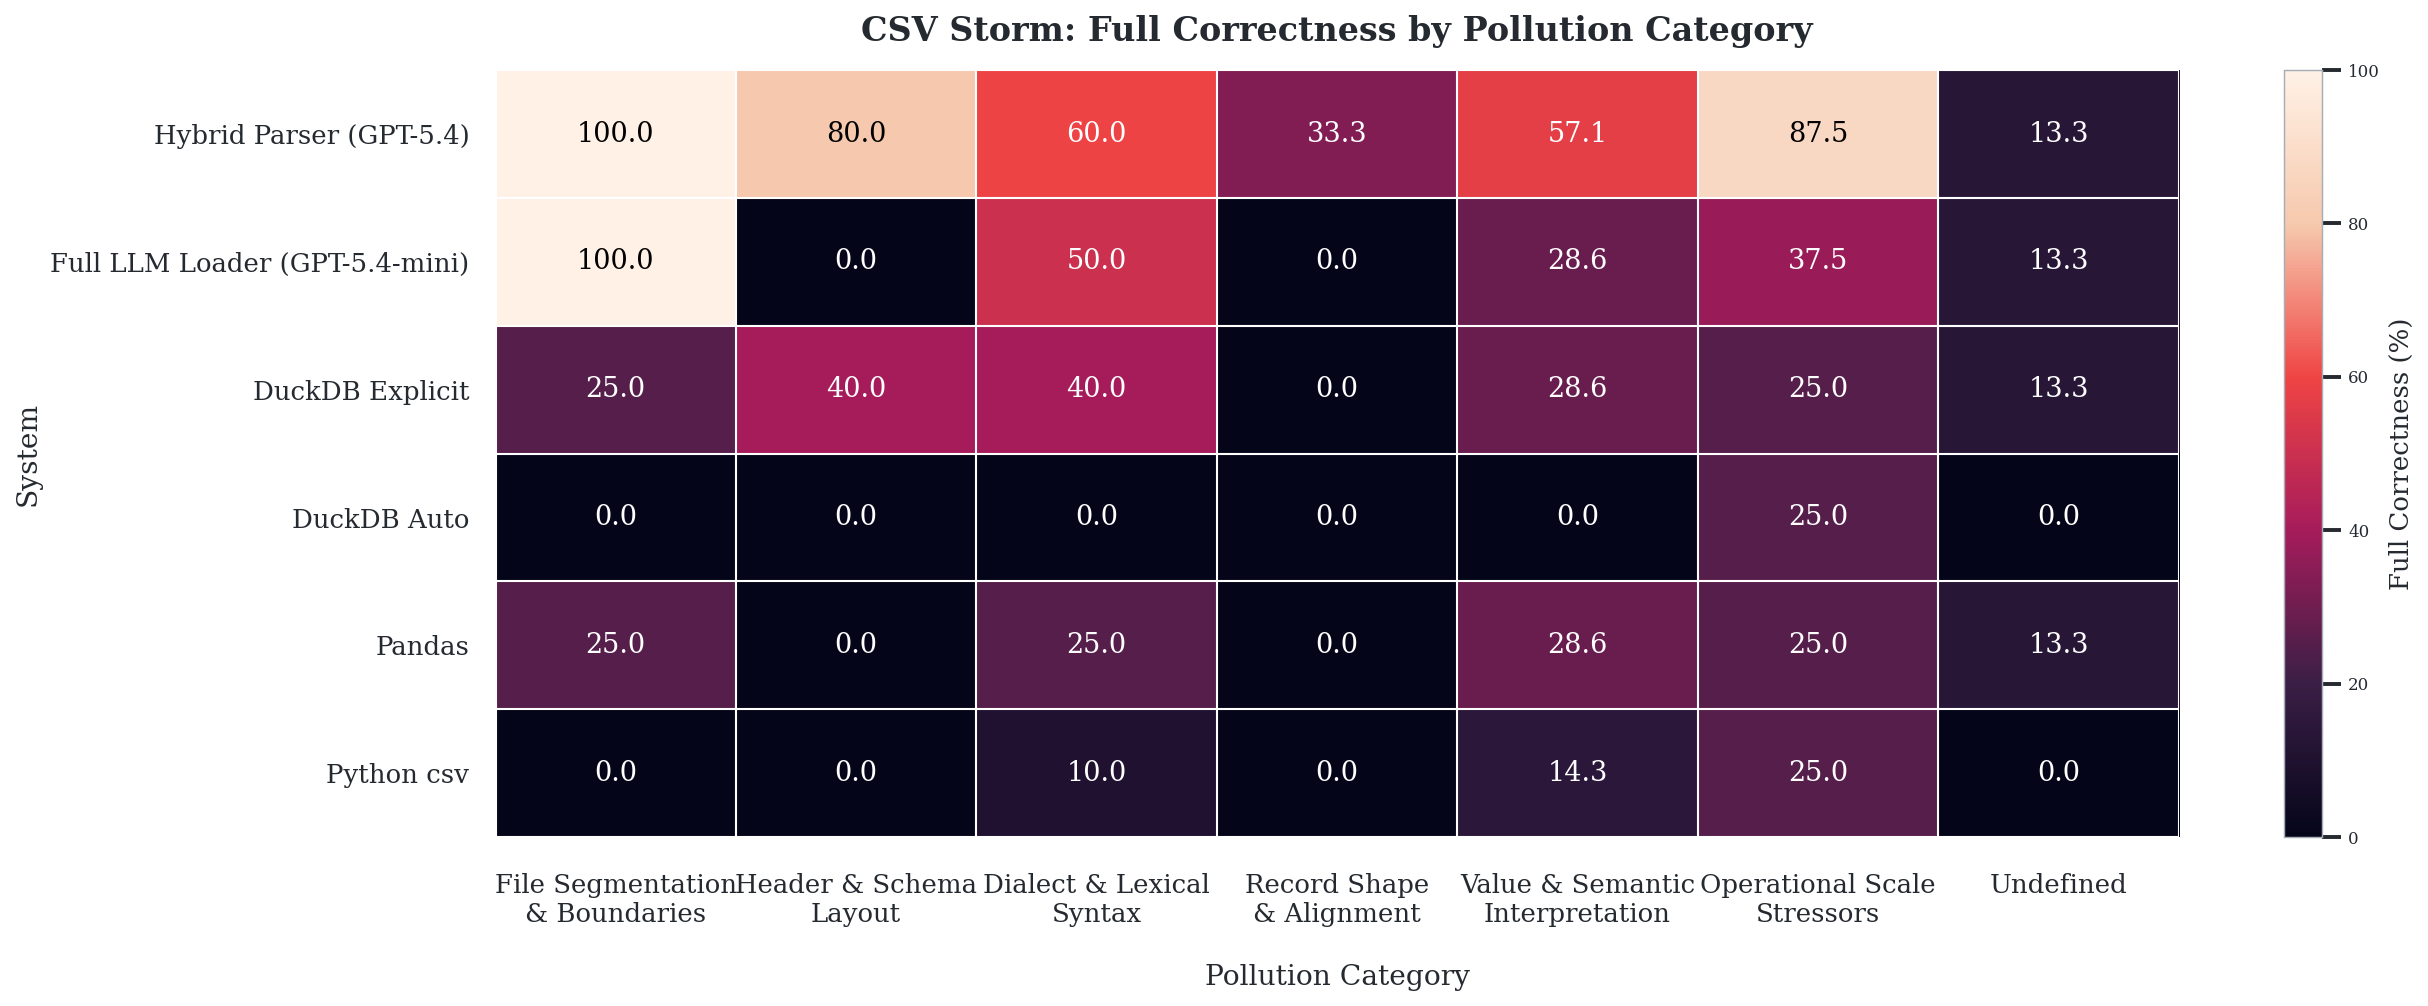

In [ ]:
# CSV Storm heatmap for the requested SUTs, in a fixed reporting order.
CSV_STORM_SUTS = [
    (
        "llm_hybrid_parser",
        f"Hybrid Parser ({display_model_name(recorded_csv_storm_model('llm_hybrid_parser'))})",
    ),
    (
        "full_llm_loader_naive_gpt_5_4_mini",
        "Full LLM Loader "
        f"({display_model_name(recorded_csv_storm_model('full_llm_loader_naive_gpt_5_4_mini'))})",
    ),
    ("duckdbparse", "DuckDB Explicit"),
    ("duckdbauto", "DuckDB Auto"),
    ("pandas", "Pandas"),
    ("pycsv", "Python csv"),
]

CATEGORY_ORDER = [
    "File Segmentation and Table-Boundary",
    "Header and Schema-Layout",
    "Dialect and Lexical-Syntax",
    "Record-Shape and Alignment",
    "Encoding and Text-Representation",
    "Value & Semantic Interpretation",
    "Operational Scale Stressor",
    "Undefined",
]

CATEGORY_DISPLAY_LABELS = {
    "File Segmentation and Table-Boundary": "File Segmentation\n& Boundaries",
    "Header and Schema-Layout": "Header & Schema\nLayout",
    "Dialect and Lexical-Syntax": "Dialect & Lexical\nSyntax",
    "Record-Shape and Alignment": "Record Shape\n& Alignment",
    "Encoding and Text-Representation": "Encoding & Text\nRepresentation",
    "Value & Semantic Interpretation": "Value & Semantic\nInterpretation",
    "Operational Scale Stressor": "Operational Scale\nStressors",
    "Undefined": "Undefined",
}

result_frames = []
for sut_id, sut_label in CSV_STORM_SUTS:
    result_path = (
        REPO_ROOT
        / "results"
        / sut_id
        / "csv_storm"
        / f"{sut_id}_results_incl_origin.csv"
    )
    sut_results = pd.read_csv(result_path)
    correct_column = f"{sut_id}_correct"
    required_columns = {"file", correct_column}
    missing_columns = required_columns.difference(sut_results.columns)
    if missing_columns:
        raise ValueError(f"{result_path} is missing columns: {sorted(missing_columns)}")

    # source.csv is the unpolluted baseline, not a heatmap pollution observation.
    sut_results = sut_results.loc[sut_results["file"] != "source.csv", ["file", correct_column]].copy()
    sut_results = sut_results.rename(columns={correct_column: "correct"})
    sut_results["sut"] = sut_label
    result_frames.append(sut_results)

csv_storm_df = pd.concat(result_frames, ignore_index=True)
csv_storm_df["polluter"] = csv_storm_df["file"].map(polluter_for_filename)

unmapped_files = sorted(csv_storm_df.loc[csv_storm_df["polluter"].isna(), "file"].unique())
if unmapped_files:
    raise ValueError(f"CSV Storm files without a polluter mapping: {unmapped_files}")

csv_storm_df["pollution_alias"] = csv_storm_df["file"].map(pollution_alias)
csv_storm_df["pollution_category"] = csv_storm_df["file"].map(pollution_category)

pollution_category_map = (
    csv_storm_df[["file", "pollution_alias", "pollution_category"]]
    .drop_duplicates()
    .sort_values(["pollution_category", "pollution_alias", "file"])
    .reset_index(drop=True)
)

# Each CSV Storm file contributes one binary correctness observation. Taking the
# mean therefore reports the percentage of fully correct files in each category.
category_scores = (
    csv_storm_df.groupby(["sut", "pollution_category"], as_index=False)["correct"]
    .mean()
)
category_scores["full_correctness_pct"] = 100 * category_scores["correct"]

sut_order = [label for _, label in CSV_STORM_SUTS]
present_categories = set(category_scores["pollution_category"])
category_order = [category for category in CATEGORY_ORDER if category in present_categories]
category_order.extend(sorted(present_categories.difference(category_order)))

heatmap_df = category_scores.pivot(
    index="sut",
    columns="pollution_category",
    values="full_correctness_pct",
).reindex(index=sut_order, columns=category_order)

# Keep the heatmap palette local so the shared notebook theme cannot alter it.
heatmap_cmap = LinearSegmentedColormap.from_list(
    "paper_reddish",
    ["#05051a", "#3b1f46", "#a61c5b", "#ef4444", "#f6c9ad", "#fff1e6"],
)
heatmap_cmap.set_bad("#d9d9d9")
masked_scores = np.ma.masked_invalid(heatmap_df.to_numpy(dtype=float))

fig_width = max(17.5, 2.45 * len(heatmap_df.columns))
fig, ax = plt.subplots(figsize=(fig_width, 7.2))
im = ax.imshow(
    masked_scores,
    cmap=heatmap_cmap,
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_xticks(np.arange(heatmap_df.shape[1]))
ax.set_yticks(np.arange(heatmap_df.shape[0]))
ax.set_xticklabels(
    [CATEGORY_DISPLAY_LABELS.get(category, category) for category in heatmap_df.columns],
    rotation=0,
    ha="center",
    fontsize=12.5,
)
ax.set_yticklabels(heatmap_df.index, fontsize=12.5)
ax.tick_params(axis="x", pad=8)

ax.set_xticks(np.arange(-0.5, heatmap_df.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, heatmap_df.shape[0], 1), minor=True)
ax.grid(False)
ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlabel("Pollution Category", fontsize=13.5, labelpad=18)
ax.set_ylabel("System", fontsize=13.5)
ax.set_title("CSV Storm: Full Correctness by Pollution Category", fontsize=16, pad=14)

for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row_idx, col_idx]
        if pd.isna(value):
            label, color = "—", "#555555"
        else:
            label = f"{value:.1f}"
            color = "black" if value >= 65 else "white"
        ax.text(
            col_idx,
            row_idx,
            label,
            ha="center",
            va="center",
            color=color,
            fontsize=13,
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Full Correctness (%)", fontsize=12.5)

plt.tight_layout()
fig.subplots_adjust(bottom=0.22)
plt.savefig(REPO_ROOT / "eval" / "CIDR_plots" / "error_heatmap.png", dpi=300)
plt.show()

### Pollock 2.0 Pollution Inventory

Pollution instances from the standard `--polluters pollock2.0` path in `pollute_main.py` (without optional per-cell pollutions), grouped by decorated category. Every `execute_polluter` call counts, and fixed-loop repetitions are shown with a multiplier.

In [ ]:
# Derive every Pollock 2.0 pollution instance directly from pollute_main.py.
import ast
from html import escape
from IPython.display import HTML


def _args_attribute(test, attribute: str) -> bool:
    return (
        isinstance(test, ast.Attribute)
        and isinstance(test.value, ast.Name)
        and test.value.id == "args"
        and test.attr == attribute
    )


def _polluter_version_comparison(test):
    if not isinstance(test, ast.Compare) or len(test.ops) != 1 or len(test.comparators) != 1:
        return None
    if not isinstance(test.ops[0], ast.Eq) or not _args_attribute(test.left, "polluters"):
        return None
    comparator = test.comparators[0]
    return comparator.value if isinstance(comparator, ast.Constant) else None


def _static_range_length(iterator) -> int:
    """Return iteration count for a literal range(...), or one when dynamic."""
    if not (
        isinstance(iterator, ast.Call)
        and isinstance(iterator.func, ast.Name)
        and iterator.func.id == "range"
    ):
        return 1
    try:
        arguments = [ast.literal_eval(argument) for argument in iterator.args]
        return len(range(*arguments))
    except (TypeError, ValueError):
        return 1


class Pollock2PolluterCollector(ast.NodeVisitor):
    """Follow Pollock 2.0 branches and preserve every generated pollution call."""

    def __init__(self):
        self.polluters = []
        self.call_multiplier = 1

    def visit_If(self, node):
        version = _polluter_version_comparison(node.test)
        if version == "pollock1.0":
            selected_statements = node.orelse
        elif version == "pollock2.0":
            selected_statements = node.body
        elif _args_attribute(node.test, "per_cell_pollutions"):
            # The standard CSV Storm generation does not pass --per-cell-pollutions.
            selected_statements = node.orelse
        else:
            selected_statements = [*node.body, *node.orelse]

        for statement in selected_statements:
            self.visit(statement)

    def visit_For(self, node):
        previous_multiplier = self.call_multiplier
        self.call_multiplier *= _static_range_length(node.iter)
        for statement in node.body:
            self.visit(statement)
        self.call_multiplier = previous_multiplier
        for statement in node.orelse:
            self.visit(statement)

    def visit_Call(self, node):
        if (
            isinstance(node.func, ast.Name)
            and node.func.id == "execute_polluter"
            and len(node.args) >= 2
            and isinstance(node.args[1], ast.Attribute)
            and isinstance(node.args[1].value, ast.Name)
            and node.args[1].value.id in {"pl", "pl2"}
        ):
            module_alias = node.args[1].value.id
            function_name = node.args[1].attr
            if function_name != "dummyPolluter":
                module = polluters_v1 if module_alias == "pl" else polluters_v2
                polluter = getattr(module, function_name)
                self.polluters.extend([polluter] * self.call_multiplier)
        self.generic_visit(node)


def _summarize_pollution_instances(values) -> str:
    counts = {}
    for value in values:
        counts[value] = counts.get(value, 0) + 1
    return ", ".join(
        f"{name} ×{count}" if count > 1 else name
        for name, count in counts.items()
    )


pollute_main_tree = ast.parse((REPO_ROOT / "pollute_main.py").read_text(encoding="utf-8"))
collector = Pollock2PolluterCollector()
collector.visit(pollute_main_tree)

active_pollock2_polluters = collector.polluters
pollock2_pollution_detail = pd.DataFrame(
    {
        "Instance": range(1, len(active_pollock2_polluters) + 1),
        "Function": [polluter.__name__ for polluter in active_pollock2_polluters],
        "Pollution": [polluter.pollution_name for polluter in active_pollock2_polluters],
        "Category": [polluter.pollution_category for polluter in active_pollock2_polluters],
    }
)

category_rank = {category: index for index, category in enumerate(CATEGORY_ORDER)}
pollock2_pollution_table = (
    pollock2_pollution_detail.groupby("Category", as_index=False, sort=False)
    .agg(
        Pollutions=("Pollution", _summarize_pollution_instances),
        Instances=("Pollution", "size"),
    )
    .assign(_rank=lambda frame: frame["Category"].map(category_rank).fillna(len(category_rank)))
    .sort_values(["_rank", "Category"])
    .drop(columns="_rank")
    .reset_index(drop=True)
)

total_pollution_instances = int(pollock2_pollution_table["Instances"].sum())
inventory_rows_html = "".join(
    "<tr>"
    f"<td class='category'>{escape(str(row.Category))}</td>"
    f"<td>{escape(str(row.Pollutions))}</td>"
    f"<td class='count'>{int(row.Instances)}</td>"
    "</tr>"
    for row in pollock2_pollution_table.itertuples(index=False)
)
pollock2_pollution_table_html = HTML(
    """
    <style>
      .pollock-inventory {
        border-collapse: collapse;
        font-size: 10.5pt;
        max-width: 1050px;
        line-height: 1.35;
      }
      .pollock-inventory th {
        background: #3b1f46;
        color: white;
        font-weight: 600;
        padding: 6px 10px;
        text-align: left;
      }
      .pollock-inventory td {
        border-bottom: 1px solid #eadde5;
        padding: 5px 10px;
        text-align: left;
        vertical-align: top;
      }
      .pollock-inventory .category {
        color: #3b1f46;
        font-weight: 600;
        min-width: 245px;
      }
      .pollock-inventory .count {
        text-align: center;
        width: 70px;
      }
      .pollock-inventory tfoot td {
        background: #f3edf1;
        border-top: 2px solid #3b1f46;
        color: #3b1f46;
        font-weight: 700;
      }
    </style>
    <table class="pollock-inventory">
      <thead><tr><th>Category</th><th>Pollution instances</th><th>Instances</th></tr></thead>
      <tbody>
    """
    + inventory_rows_html
    + "</tbody>"
    + "<tfoot><tr><td colspan='2'>Total pollution instances</td>"
    + f"<td class='count'>{total_pollution_instances}</td></tr></tfoot></table>"
)
pollock2_pollution_table_html

## Evaluation 3 - Runtime and Cost Arguments

In [ ]:
# Cost per 1M tokens 

OPENAI_MODEL_PRICING = {
    "gpt-5": {
        "input": 0.625,
        "cached_input": 0.0625,
        "output": 5.00,
    },
    "gpt-5.1": {
        "input": 0.625,
        "cached_input": 0.0625,
        "output": 5.00,
    },
    "gpt-5.2": {
        "input": 0.875,
        "cached_input": 0.0875,
        "output": 7.00,
    },
    "gpt-5-mini": {
        "input": 0.125,
        "cached_input": 0.0125,
        "output": 1.00,
    },
    "gpt-5-nano": {
        "input": 0.025,
        "cached_input": 0.0025,
        "output": 0.20,
    },
    "gpt-5-pro": {
        "input": 7.50,
        "cached_input": None,
        "output": 60.00,
    },
    "gpt-5.2-pro": {
        "input": 10.50,
        "cached_input": None,
        "output": 84.00,
    },
    "gpt-4.1": {
        "input": 1.00,
        "cached_input": None,
        "output": 4.00,
    },
    "gpt-4.1-mini": {
        "input": 0.20,
        "cached_input": None,
        "output": 0.80,
    },
    "gpt-4.1-nano": {
        "input": 0.05,
        "cached_input": None,
        "output": 0.20,
    },
    "gpt-4o": {
        "input": 1.25,
        "cached_input": None,
        "output": 5.00,
    },
    "gpt-4o-mini": {
        "input": 0.075,
        "cached_input": None,
        "output": 0.30,
    },
}

In [ ]:
def calc_openai_runcost(model, uncached_input_tokens, cached_input_tokens, completion_tokens):
    """Calculates the total cost of an OpenAI API call."""

    pricing = OPENAI_MODEL_PRICING[model]

    input_price, cached_input_price, output_price = pricing["input"], pricing["cached_input"], pricing["output"]

    input_cost = uncached_input_tokens * input_price / 1_000_000
    output_cost = completion_tokens * output_price / 1_000_000

    if cached_input_price is None:
        # Models without cached pricing charge the normal input rate
        cached_input_cost = cached_input_tokens * input_price / 1_000_000
    else:
        cached_input_cost = cached_input_tokens * cached_input_price / 1_000_000

    return input_cost + cached_input_cost + output_cost

In [ ]:
# Path to your CSV file
# csv_path = "/home/neubauer/src/pollock-offsite/results/full_llm_loader_naive/csv_storm/full_llm_loader_naive_time.csv"

csv_path = "/home/neubauer/src/pollock-offsite/results/full_llm_loader_guided/csv_storm/full_llm_loader_guided_time.csv"
# Load the CSV
df = pd.read_csv(csv_path)

# Display the first few rows
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/neubauer/src/pollock-offsite/results/full_llm_loader_guided/csv_storm/full_llm_loader_guided_time.csv'

In [ ]:
# Calculate cost file wise 
df["run_cost"] = df.apply(
    lambda row: calc_openai_runcost(
        model=row["model"],
        uncached_input_tokens=row["uncached_input_tokens_0"],
        cached_input_tokens=row["cached_input_tokens_0"],
        completion_tokens=row["completion_tokens_0"],
    ),
    axis=1,)

# Sum to get cost estimate for one benchmark run 
print(f"Total cost for run: ${df['run_cost'].sum():.6f}")

Total cost for run: $0.091822
